In [1]:
import pandas, supervenn

In [2]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

4
192
230
140 180 49
['ENSMUSG00000000031', 'ENSMUSG00000000184', 'ENSMUSG00000000290', 'ENSMUSG00000000318', 'ENSMUSG00000002265', 'ENSMUSG00000002831', 'ENSMUSG00000007682', 'ENSMUSG00000008845', 'ENSMUSG00000012705', 'ENSMUSG00000015476', 'ENSMUSG00000017344', 'ENSMUSG00000019124', 'ENSMUSG00000019577', 'ENSMUSG00000019932', 'ENSMUSG00000020098', 'ENSMUSG00000020431', 'ENSMUSG00000020911', 'ENSMUSG00000020937', 'ENSMUSG00000021390', 'ENSMUSG00000021478', 'ENSMUSG00000022206', 'ENSMUSG00000022595', 'ENSMUSG00000022667', 'ENSMUSG00000022878', 'ENSMUSG00000022935', 'ENSMUSG00000023046', 'ENSMUSG00000023274', 'ENSMUSG00000024112', 'ENSMUSG00000024261', 'ENSMUSG00000024371', 'ENSMUSG00000024503', 'ENSMUSG00000024511', 'ENSMUSG00000024529', 'ENSMUSG00000024677', 'ENSMUSG00000024679', 'ENSMUSG00000025044', 'ENSMUSG00000025479', 'ENSMUSG00000026023', 'ENSMUSG00000026475', 'ENSMUSG00000026676', 'ENSMUSG00000026697', 'ENSMUSG00000026890', 'ENSMUSG00000027513', 'ENSMUSG00000028033', 'ENSMUSG00

/var/folders/j2/645ctp717nv8rwbn2dsccyxh0000gn/T/ipykernel_31119/48160985.py:34: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  annotation = pandas.read_csv('/Users/adrian/software/kallisto/mouse_index_standard/t2g.txt', sep='\t', header=None)


49
Klf4
Emb
Vdr
Trp63
Serinc2
Slc16a3
Urah
Slc40a1
Ptprc
Pkp1
Selp
Spint1
Siglec1
Plbd1
Cidec
Hp
Trim29
Dpyd
Asprv1
Ly6d
Vax2
Lars2
Krt80
Tcfl5
Igfbp2
Mreg
Saa3
Apoc1
Ppp1r13l
S100a14
Ifi209
Zfp758
Krt14
Ccr2
Sorl1
Fam110d
Sprr1a
Lgals7
Krt16
Pkp3
Dsp
Krt6a
C1qtnf3
Dmkn
mt-Atp8
Zfp991
Col6a5
Rmrp
Gm7072


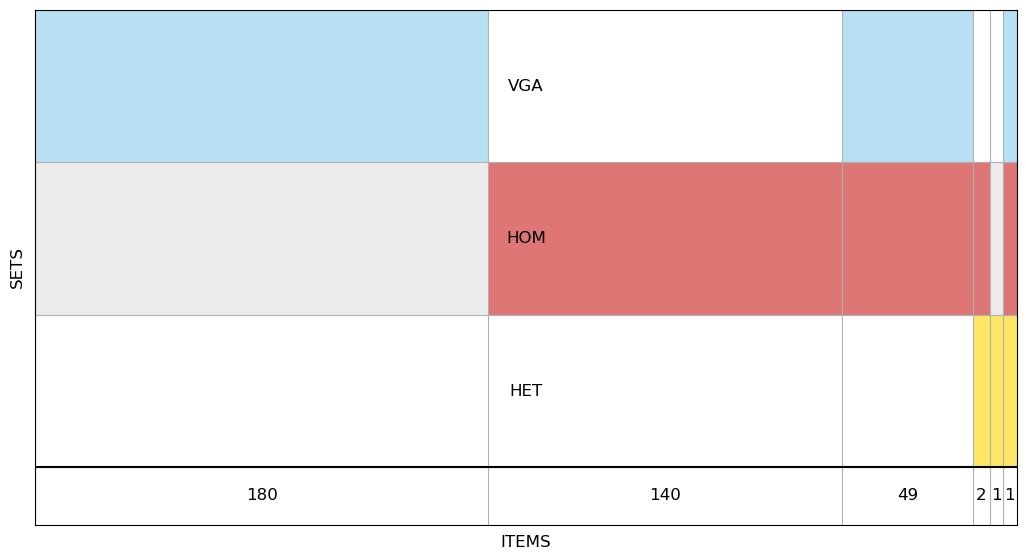

In [18]:



input_dir = '/Users/adrian/research/bmcbf/029_orsay/results/001.degs/'

df = pandas.read_csv(input_dir+'effect_HET_vs_WT.woo.for.tsv', sep='\t', index_col=0)
a = set(df.index)
print(len(a))

df = pandas.read_csv(input_dir+'effect_HOM_vs_WT.woo.for.tsv', sep='\t', index_col=0)
b = set(df.index)
print(len(b))

df = pandas.read_csv(input_dir+'effect_VGA_vs_WT.woo.for.tsv', sep='\t', index_col=0)
c = set(df.index)
print(len(c))

sets = [a, b, c]
labels = ['HET', 'HOM', 'VGA']
mso = supervenn.supervenn(sets, labels, chunks_ordering='size',
                          side_plots=False, widths_minmax_ratio=0.03, 
                          reverse_sets_order=False, fontsize=12, color_cycle=['gold', 'tab:red', 'skyblue'])


matplotlib.pyplot.tight_layout()

onlyhom = list(mso.get_chunk([1]))
onlyvga = list(mso.get_chunk([2]))
both = list(mso.get_chunk([1,2]))
print(len(onlyhom), len(onlyvga), len(both))

onlyhom.sort()
print(onlyhom)
onlyvga.sort()
both.sort()

annotation = pandas.read_csv('/Users/adrian/software/kallisto/mouse_index_standard/t2g.txt', sep='\t', header=None)
nodots = annotation[1].str.split('.', expand=True)
annotation['nodots'] = nodots[0]

selected_set = both
print(len(selected_set))

for i in range(len(selected_set)):    
    element = selected_set[i]
    most_likely = list(set(annotation[annotation['nodots'] == element][2]))
    if len(most_likely) != 1:
        print(most_likely)
        raise ValueError("Something went wrong. Stopping execution.")
    if type(most_likely[0]) == str:
        print(most_likely[0])
    else:
        print(element)


1 3
123 69
218 12


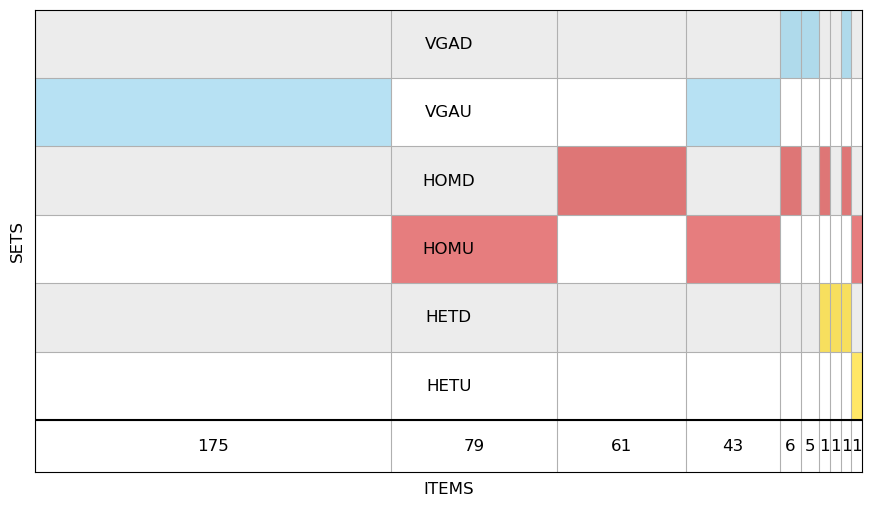

In [4]:
input_dir = '/Users/adrian/research/bmcbf/029_orsay/results/001.degs/'

df = pandas.read_csv(input_dir+'effect_HET_vs_WT.woo.for.tsv', sep='\t', index_col=0)
dfup = df[df['log2FoldChange'] > 0]; dfdown = df[df['log2FoldChange'] < 0]
au = set(dfup.index); ad = set(dfdown.index)
print(len(au), len(ad))

df = pandas.read_csv(input_dir+'effect_HOM_vs_WT.woo.for.tsv', sep='\t', index_col=0)
dfup = df[df['log2FoldChange'] > 0]; dfdown = df[df['log2FoldChange'] < 0]
bu = set(dfup.index); bd = set(dfdown.index)
print(len(bu), len(bd))

df = pandas.read_csv(input_dir+'effect_VGA_vs_WT.woo.for.tsv', sep='\t', index_col=0)
dfup = df[df['log2FoldChange'] > 0]; dfdown = df[df['log2FoldChange'] < 0]
cu = set(dfup.index); cd = set(dfdown.index)
print(len(cu), len(cd))

sets = [au, ad, bu, bd, cu, cd]
labels = ['HETU', 'HETD', 'HOMU', 'HOMD', 'VGAU', 'VGAD']
mso = supervenn.supervenn(sets, labels, chunks_ordering='size',
                          side_plots=False, widths_minmax_ratio=0.03, 
                          reverse_sets_order=False, fontsize=12, color_cycle=['gold', 'gold', 'tab:red', 'tab:red', 'skyblue', 'skyblue'])

matplotlib.pyplot.show()